In [1]:
import pandas as pd
import numpy as np
import sqlite3

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
conn = sqlite3.connect("../../data/warehouse/saas.db")

In [4]:
df = pd.read_sql_query(
    "SELECT * FROM customer_360",
    conn
)

df.head()

,user_id,country,industry,company_size,plan_type,monthly_revenue,is_churned,total_usage_events,avg_session_duration,total_tickets,avg_resolution_time,avg_satisfaction,total_campaign_engagements,email_open_rate,click_rate
0,1,USA,SaaS,Enterprise,Pro,150,0,54,33.648148,0,NaN,NaN,15,0.666667,0.533333
1,2,India,Healthcare,Small,Basic,50,1,7,4.714286,3,69.333333,4.333333,2,0.000000,0.500000
2,3,UK,SaaS,Enterprise,Basic,50,1,13,5.230769,6,60.833333,3.666667,1,1.000000,0.000000
3,4,Canada,SaaS,Enterprise,Basic,50,0,99,34.747475,0,NaN,NaN,8,0.750000,0.750000
4,5,Germany,SaaS,Small,Basic,50,0,117,33.512821,4,16.250000,7.250000,11,0.545455,0.545455


In [7]:
print(df.shape)
print(df.info())
print(df.describe())
print(df.head())

(5000, 15)
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   user_id                     5000 non-null   int64  
 1   country                     5000 non-null   str    
 2   industry                    5000 non-null   str    
 3   company_size                5000 non-null   str    
 4   plan_type                   5000 non-null   str    
 5   monthly_revenue             5000 non-null   int64  
 6   is_churned                  5000 non-null   int64  
 7   total_usage_events          5000 non-null   int64  
 8   avg_session_duration        5000 non-null   float64
 9   total_tickets               5000 non-null   int64  
 10  avg_resolution_time         4273 non-null   float64
 11  avg_satisfaction            4273 non-null   float64
 12  total_campaign_engagements  5000 non-null   int64  
 13  email_open_rate             5000 

In [8]:
df["is_churned"].value_counts()

is_churned
0    3637
1    1363
Name: count, dtype: int64

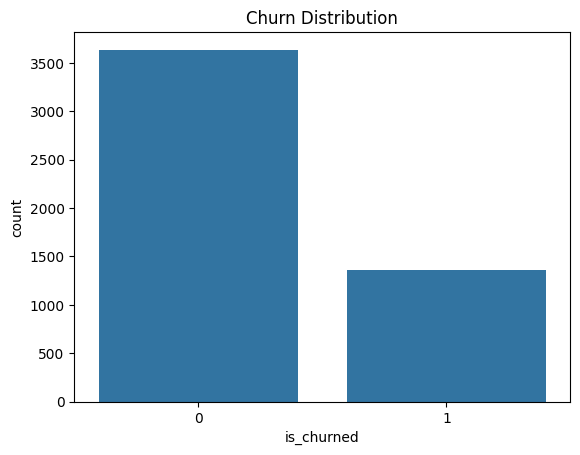

In [9]:
sns.countplot(
    data=df,
    x="is_churned"
)

plt.title("Churn Distribution")

plt.show()

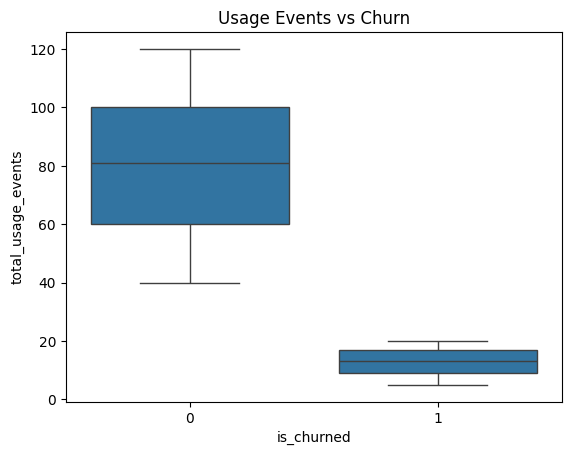

In [10]:
sns.boxplot(
    data=df,
    x="is_churned",
    y="total_usage_events"
)

plt.title("Usage Events vs Churn")

plt.show()

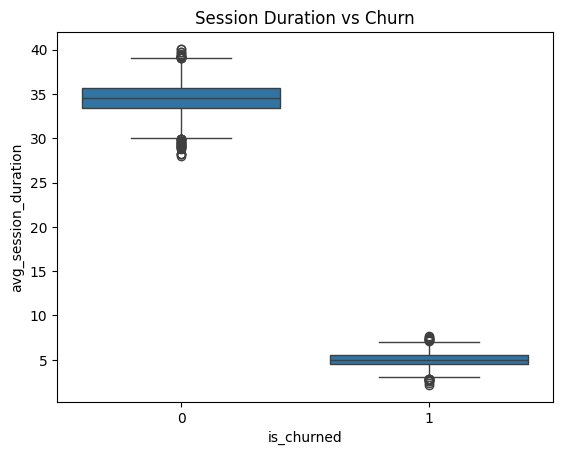

In [11]:
sns.boxplot(
    data=df,
    x="is_churned",
    y="avg_session_duration"
)

plt.title("Session Duration vs Churn")

plt.show()

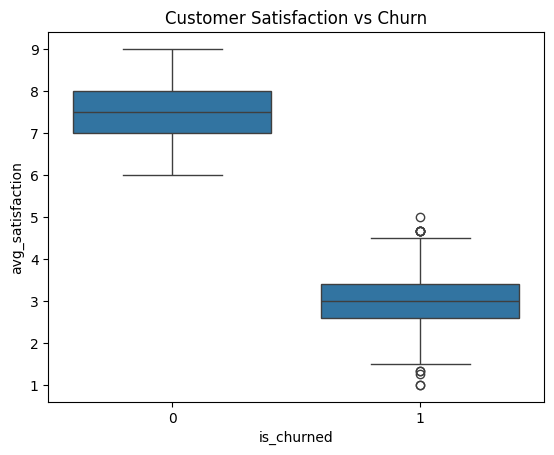

In [12]:
sns.boxplot(
    data=df,
    x="is_churned",
    y="avg_satisfaction"
)

plt.title("Customer Satisfaction vs Churn")

plt.show()

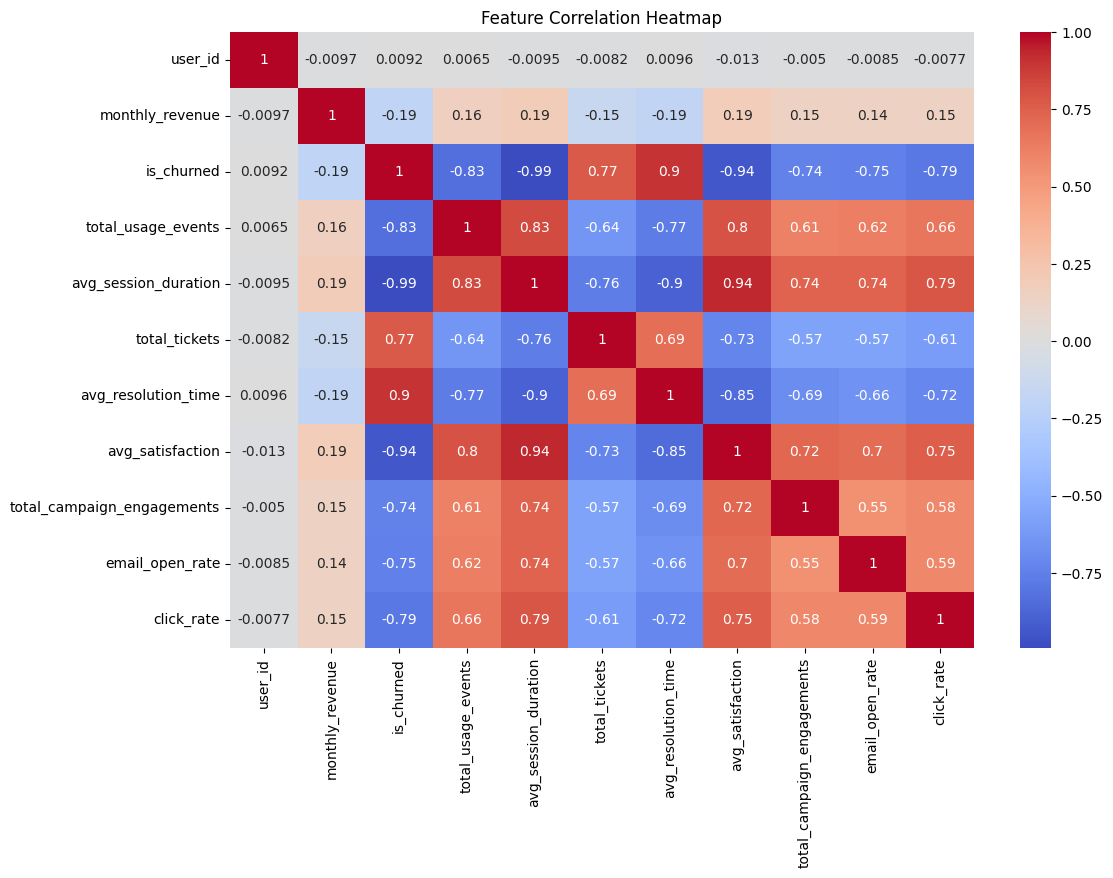

In [13]:
numeric_df = df.select_dtypes(include=np.number)

corr = numeric_df.corr()

plt.figure(figsize=(12,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [14]:
users_df = pd.read_sql_query(
    """
    SELECT
        u.user_id,
        u.signup_date,
        s.is_churned
    FROM users u
    JOIN subscriptions s
    ON u.user_id = s.user_id
    """,
    conn
)

users_df.head()

,user_id,signup_date,is_churned
0,1,2025-10-08,0
1,2,2025-12-12,1
2,3,2025-05-15,1
3,4,2025-01-02,0
4,5,2024-11-09,0


In [15]:
users_df["signup_date"] = pd.to_datetime(
    users_df["signup_date"]
)

In [16]:
users_df["cohort_month"] = users_df[
    "signup_date"
].dt.to_period("M")

In [17]:
cohort_counts = users_df.groupby(
    "cohort_month"
)["user_id"].count()

cohort_counts

cohort_month
2024-05     87
2024-06    199
2024-07    208
2024-08    196
2024-09    214
2024-10    218
2024-11    219
2024-12    197
2025-01    199
2025-02    196
2025-03    235
2025-04    222
2025-05    223
2025-06    203
2025-07    225
2025-08    225
2025-09    199
2025-10    197
2025-11    178
2025-12    224
2026-01    209
2026-02    189
2026-03    200
2026-04    204
2026-05    134
Freq: M, Name: user_id, dtype: int64

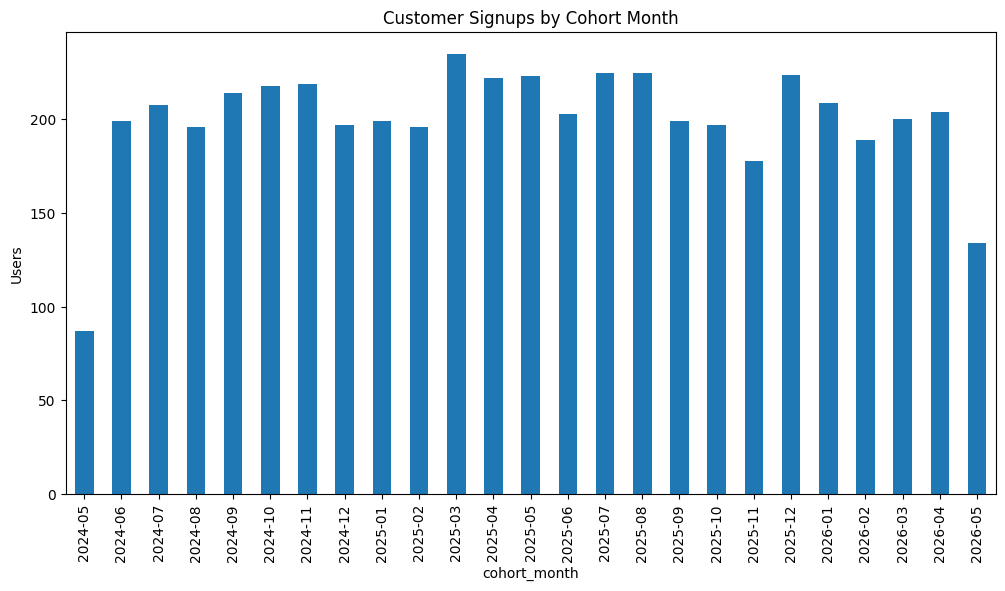

In [18]:
cohort_counts.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Customer Signups by Cohort Month")

plt.ylabel("Users")

plt.show()

In [19]:
cohort_churn = users_df.groupby(
    "cohort_month"
)["is_churned"].mean()

cohort_churn

cohort_month
2024-05    0.229885
2024-06    0.296482
2024-07    0.283654
2024-08    0.280612
2024-09    0.294393
2024-10    0.261468
2024-11    0.305936
2024-12    0.284264
2025-01    0.246231
2025-02    0.280612
2025-03    0.225532
2025-04    0.324324
2025-05    0.228700
2025-06    0.270936
2025-07    0.257778
2025-08    0.271111
2025-09    0.296482
2025-10    0.243655
2025-11    0.258427
2025-12    0.290179
2026-01    0.215311
2026-02    0.280423
2026-03    0.365000
2026-04    0.250000
2026-05    0.246269
Freq: M, Name: is_churned, dtype: float64

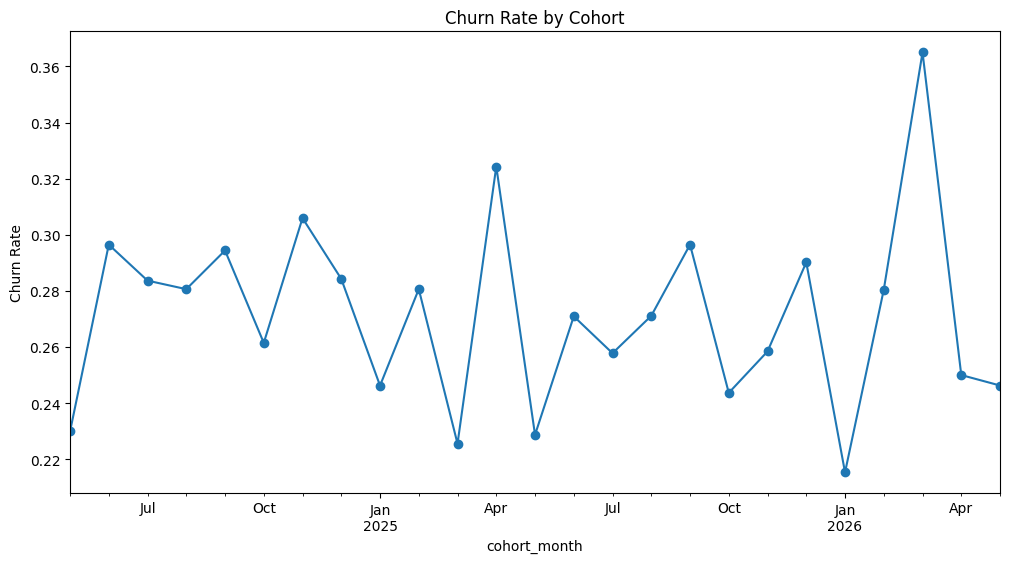

In [20]:
cohort_churn.plot(
    kind="line",
    marker="o",
    figsize=(12,6)
)

plt.title("Churn Rate by Cohort")

plt.ylabel("Churn Rate")

plt.show()

In [21]:
plan_churn = df.groupby(
    "plan_type"
)["is_churned"].mean()

plan_churn

plan_type
Basic         0.351578
Enterprise    0.081871
Pro           0.181577
Name: is_churned, dtype: float64

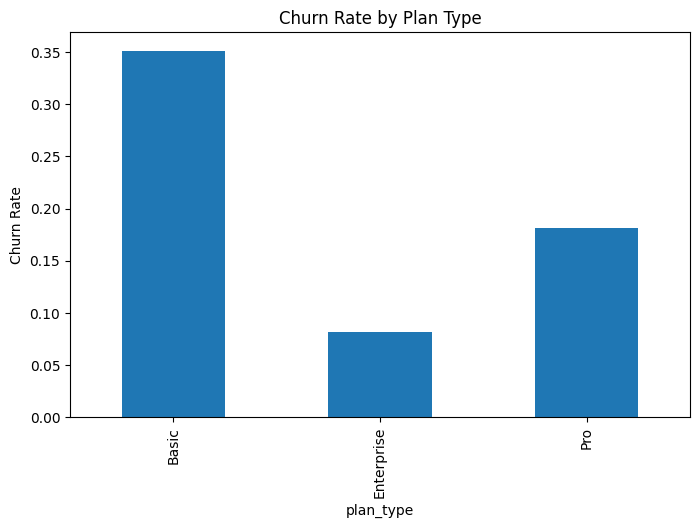

In [22]:
plan_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Plan Type")

plt.ylabel("Churn Rate")

plt.show()

In [23]:
country_churn = df.groupby(
    "country"
)["is_churned"].mean()

country_churn.sort_values()

country
UK         0.254797
Canada     0.270484
Germany    0.275404
USA        0.275897
India      0.285015
Name: is_churned, dtype: float64

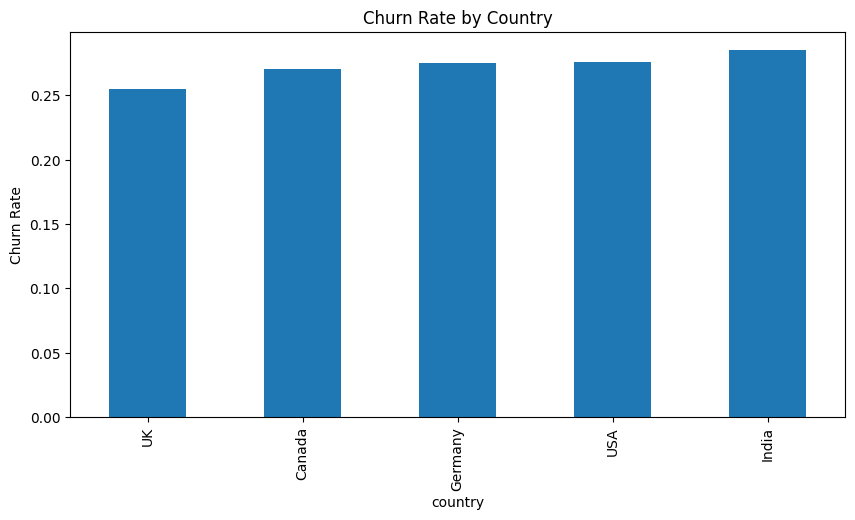

In [24]:
country_churn.sort_values().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Churn Rate by Country")

plt.ylabel("Churn Rate")

plt.show()

In [25]:
size_churn = df.groupby(
    "company_size"
)["is_churned"].mean()

size_churn

company_size
Enterprise    0.257349
Medium        0.277576
Small         0.282828
Name: is_churned, dtype: float64

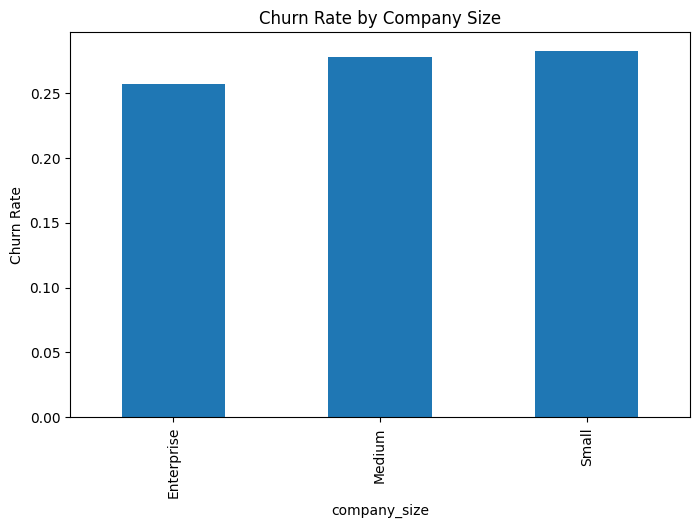

In [26]:
size_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Company Size")

plt.ylabel("Churn Rate")

plt.show()